In [1]:
import pandas as pd

In [2]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

In [3]:
import numpy as np

In [4]:
import seaborn as sb

In [5]:
import os

In [6]:
import joblib

In [7]:
os.getcwd()

'C:\\Users\\AKILAN M'

In [8]:
os.chdir(r"C:\Users\AKILAN M\Downloads")

In [9]:
import zipfile

In [10]:
with zipfile.ZipFile("telco.csv.zip","r") as f:
            f.extractall("telco")
      

In [11]:
os.chdir(r"C:\Users\AKILAN M\Downloads\telco")

In [12]:
ibm = os.listdir()

In [13]:
ibm

['app.py',
 'clustering_model.pkl',
 'clustering_model_pca_kmean.pkl',
 'clustering_model_umap_HDBSCAN.pkl',
 'model',
 'telco.csv']

# Dataset Exploration

In [14]:
ibdata = pd.read_csv('telco.csv')

In [15]:
data = pd.read_csv('telco.csv')

In [16]:
data.head()

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,City,Zip Code,Latitude,Longitude,Population,Quarter,Referred a Friend,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,Internet Type,Avg Monthly GB Download,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,Los Angeles,90022,34.023810,-118.156582,68701,Q3,No,0,1,NaN,No,0.00,No,Yes,DSL,8,No,No,Yes,No,No,Yes,No,No,Month-to-Month,Yes,Bank Withdrawal,39.65,39.65,0.00,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,Los Angeles,90063,34.044271,-118.185237,55668,Q3,Yes,1,8,Offer E,Yes,48.85,Yes,Yes,Fiber Optic,17,No,Yes,No,No,No,No,No,Yes,Month-to-Month,Yes,Credit Card,80.65,633.30,0.00,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,Los Angeles,90065,34.108833,-118.229715,47534,Q3,No,0,18,Offer D,Yes,11.33,Yes,Yes,Fiber Optic,52,No,No,No,No,Yes,Yes,Yes,Yes,Month-to-Month,Yes,Bank Withdrawal,95.45,1752.55,45.61,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,Inglewood,90303,33.936291,-118.332639,27778,Q3,Yes,1,25,Offer C,Yes,19.76,No,Yes,Fiber Optic,12,No,Yes,Yes,No,Yes,Yes,No,Yes,Month-to-Month,Yes,Bank Withdrawal,98.50,2514.50,13.43,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,Whittier,90602,33.972119,-118.020188,26265,Q3,Yes,1,37,Offer C,Yes,6.33,Yes,Yes,Fiber Optic,14,No,No,No,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,76.50,2868.15,0.00,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [17]:
## Customers unique IDs
len(data["Customer ID"].unique())

7043

In [18]:
data.shape ## The Data Comes with 7043 unique customer IDs with 50 features inclues Churn Labels and Churn Reasons

(7043, 50)

In [19]:
ibdata["Churn Label"].value_counts() ## Labels distinct count of Churn and Non churn Customers

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [20]:
data.describe()

,Age,Number of Dependents,Zip Code,Latitude,Longitude,Population,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Churn Score,CLTV
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,46.509726,0.468692,93486.070567,36.197455,-119.756684,22139.603294,1.951867,32.386767,22.958954,20.515405,64.761692,2280.381264,1.962182,6.860713,749.099262,3034.379056,3.244924,58.505040,4400.295755
std,16.750352,0.962802,1856.767505,2.468929,2.154425,21152.392837,3.001199,24.542061,15.448113,20.418940,30.090047,2266.220462,7.902614,25.104978,846.660055,2865.204542,1.201657,21.170031,1183.057152
min,19.000000,0.000000,90001.000000,32.555828,-124.301372,11.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.000000,0.000000,0.000000,21.360000,1.000000,5.000000,2003.000000
25%,32.000000,0.000000,92101.000000,33.990646,-121.788090,2344.000000,0.000000,9.000000,9.210000,3.000000,35.500000,400.150000,0.000000,0.000000,70.545000,605.610000,3.000000,40.000000,3469.000000
50%,46.000000,0.000000,93518.000000,36.205465,-119.595293,17554.000000,0.000000,29.000000,22.890000,17.000000,70.350000,1394.550000,0.000000,0.000000,401.440000,2108.640000,3.000000,61.000000,4527.000000
75%,60.000000,0.000000,95329.000000,38.161321,-117.969795,36125.000000,3.000000,55.000000,36.395000,27.000000,89.850000,3786.600000,0.000000,0.000000,1191.100000,4801.145000,4.000000,75.500000,5380.500000
max,80.000000,9.000000,96150.000000,41.962127,-114.192901,105285.000000,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000,5.000000,96.000000,6500.000000


## Customer Age Distribution:  Mean age: 46.5 Min: 19 Max: 80
## Most customers are middle-aged adults.
## Telecom services are mainly used by working-age population.
## Younger customers may churn more due to higher mobility and competition sensitivity.
## -------------------------------------------------------------------------------------------------------------------------------

## Dependents Average: 0.46 Median: 0 Max: 9
## Customers without dependents may switch providers more easily,increasing churn probability.
## -------------------------------------------------------------------------------------------------------------------------------

## Tenure Distribution Mean: 32 months Median: 29 months Max: 72 months
## Customers stay around 32 months on average.
## -------------------------------------------------------------------------------------------------------------------------------

## Number of Referrals: Customers have made an average of about 2 referrals.
## However, the median is 0, suggesting that many customers have not made any referrals.
## Some customers have referred up to 11 people.
## -------------------------------------------------------------------------------------------------------------------------------

## Tenure in Months: The average customer tenure is about 32 months.
## The tenure ranges from 1 month to 72 months.
## Half of the customers have tenure between 9 and 55 months, showing a wide range of customer retention.
## -------------------------------------------------------------------------------------------------------------------------------

## Monthly Charges: The average monthly charge is about dlr 64.76.
## Monthly charges range from dlr 18.25 to dlr 118.75, indicating a variety of pricing plans.
## Half of the customers pay between dlr 35.50 and dlr 89.85 per month.
## -------------------------------------------------------------------------------------------------------------------------------

## Average Monthly GB Download
## Customers download an average of about 20.5 GB per month.
## Data usage ranges from 0 GB to 85 GB, showing significant variation in internet consumption.
## -------------------------------------------------------------------------------------------------------------------------------

## Average Monthly Long Distance Charges
## Customers spend an average of  22.96 on long-distance charges per month.
## Charges vary from  0 to about 49.99, indicating that some customers do not use long-distance services.
## -------------------------------------------------------------------------------------------------------------------------------

## Total Charges
## The average total charge per customer is approximately  2280.
## The values range from  18.8 to  8684.8, showing a wide distribution in total spending
## -------------------------------------------------------------------------------------------------------------------------------

## Total Revenue
## The average revenue generated per customer is about 3034.
## Revenue varies significantly, with a maximum of 11,979.
## -------------------------------------------------------------------------------------------------------------------------------

## Satisfaction Score
## Customer satisfaction scores range from 1 to 5.
## The average satisfaction score is 3.24, indicating that customers are generally moderately satisfied.
## -------------------------------------------------------------------------------------------------------------------------------

## Churn Score
## The churn score ranges from 5 to 96.
## The average churn score is approximately 58.5, suggesting varying levels of churn risk among customers.
## -------------------------------------------------------------------------------------------------------------------------------

## Customer Lifetime Value (CLTV)
## The average CLTV is around 4400.
## Values range from 2003 to 6500, indicating differences in long-term customer value.

In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Under 30                           7043 non-null   object 
 4   Senior Citizen                     7043 non-null   object 
 5   Married                            7043 non-null   object 
 6   Dependents                         7043 non-null   object 
 7   Number of Dependents               7043 non-null   int64  
 8   Country                            7043 non-null   object 
 9   State                              7043 non-null   object 
 10  City                               7043 non-null   object 
 11  Zip Code                           7043 non-null   int64

# Customer Demographics
## Information describing the customer profile.
## Customer ID, Gender, Age, Under 30, Senior Citizen, Married, Dependents,Number of Dependents
## Purpose: Used to understand customer characteristics and segments.

## --------------------------------------------------------------------------------------------------------------------------------
# Geographic Information
## Location-related data.
## Country, State, City, Zip Code, Latitude, Longitude, Population
## Purpose: Helps analyze regional patterns in churn or revenue.
## ---------------------------------------------------------------------------------------------------------------------------------

# Referral and Marketing Data
## Customer engagement and referrals.
## Referred a Friend, Number of Referrals, Offer, Quarter
## Purpose: Used to study marketing effectiveness and referral impact.

## ---------------------------------------------------------------------------------------------------------------------------------
## Customer Tenure & Relationship
## Customer relationship duration.
## Tenure in Months, Contract, Purpose
## Purpose: Shows how long customers stay with the company.
## ---------------------------------------------------------------------------------------------------------------------------------

## Service Subscription Features
## Services the customer has subscribed to.
## Phone Service, Multiple Lines, Internet Service, Internet Type, 
## Online Security,Online Backup, Device Protection Plan, Premium Tech Support
##  Purpose: Indicates service adoption and bundles.
## ---------------------------------------------------------------------------------------------------------------------------------

## Streaming & Data Services
## Entertainment and internet usage.
## Streaming TV,Streaming Movies, Streaming Music, Unlimited Data, Avg Monthly GB Download
## Purpose: Shows customer entertainment usage and data consumption.

## ---------------------------------------------------------------------------------------------------------------------------------

## Billing and Payment Information
## Billing preferences and payment behavior.
## Paperless Billing, Payment Method, Monthly Charge
## Purpose: Used to analyze payment habits and billing preferences.
## ---------------------------------------------------------------------------------------------------------------------------------

## Revenue and Financial Metrics
## Customer financial contribution.
## Total Charges, Total Refunds, Total Extra Data Charges, Total Long Distance Charges,
## Total Revenue, CLTV
## Purpose: Used to analyze customer value and profitability.
## ---------------------------------------------------------------------------------------------------------------------------------

## Usage Charges
## Charges based on usage.
## Avg Monthly Long Distance Charges
## Purpose: Shows telecom usage behavior.
## ---------------------------------------------------------------------------------------------------------------------------------

## Customer Experience
## Customer satisfaction indicators: Satisfaction Score
## Purpose: Measures customer experience and satisfaction level.
## --------------------------------------------------------------------------------------------------------------------------------

# EDA Exploratory Data Analysis
## Columns List

In [22]:
print(*ibdata.columns, sep="\n")

Customer ID
Gender
Age
Under 30
Senior Citizen
Married
Dependents
Number of Dependents
Country
State
City
Zip Code
Latitude
Longitude
Population
Quarter
Referred a Friend
Number of Referrals
Tenure in Months
Offer
Phone Service
Avg Monthly Long Distance Charges
Multiple Lines
Internet Service
Internet Type
Avg Monthly GB Download
Online Security
Online Backup
Device Protection Plan
Premium Tech Support
Streaming TV
Streaming Movies
Streaming Music
Unlimited Data
Contract
Paperless Billing
Payment Method
Monthly Charge
Total Charges
Total Refunds
Total Extra Data Charges
Total Long Distance Charges
Total Revenue
Satisfaction Score
Customer Status
Churn Label
Churn Score
CLTV
Churn Category
Churn Reason


In [23]:
num_cols = ibdata.select_dtypes(include=['number']).columns.tolist()
cat_cols = ibdata.select_dtypes(include=['object']).columns.tolist()


In [24]:
## Numerical Columns
num_cols

['Age',
 'Number of Dependents',
 'Zip Code',
 'Latitude',
 'Longitude',
 'Population',
 'Number of Referrals',
 'Tenure in Months',
 'Avg Monthly Long Distance Charges',
 'Avg Monthly GB Download',
 'Monthly Charge',
 'Total Charges',
 'Total Refunds',
 'Total Extra Data Charges',
 'Total Long Distance Charges',
 'Total Revenue',
 'Satisfaction Score',
 'Churn Score',
 'CLTV']

In [25]:
## Numer of Numerical Columns
print(f"The Nummber of Numerical Columns in Dataset is {len(num_cols)}")

The Nummber of Numerical Columns in Dataset is 19


In [26]:
print(f"The number of Categorical column in Daytaset is {len(cat_cols)}")

The number of Categorical column in Daytaset is 31


In [27]:
## categorical columns
cat_cols

['Customer ID',
 'Gender',
 'Under 30',
 'Senior Citizen',
 'Married',
 'Dependents',
 'Country',
 'State',
 'City',
 'Quarter',
 'Referred a Friend',
 'Offer',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Internet Type',
 'Online Security',
 'Online Backup',
 'Device Protection Plan',
 'Premium Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Streaming Music',
 'Unlimited Data',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Customer Status',
 'Churn Label',
 'Churn Category',
 'Churn Reason']

In [28]:
## The function for identifing Unique categories 
def uni(c):
    for i in c:
            d = ibdata[i].unique()
            print(f"The unique values of column {i} are {d}")
            print("--"*50)
        

## Unique categories in Categorical (Object columns)

In [29]:
## Unique categories in Categorical columns

uni(cat_cols)

The unique values of column Customer ID are ['8779-QRDMV' '7495-OOKFY' '1658-BYGOY' ... '2234-XADUH' '4801-JZAZL'
 '3186-AJIEK']
----------------------------------------------------------------------------------------------------
The unique values of column Gender are ['Male' 'Female']
----------------------------------------------------------------------------------------------------
The unique values of column Under 30 are ['No' 'Yes']
----------------------------------------------------------------------------------------------------
The unique values of column Senior Citizen are ['Yes' 'No']
----------------------------------------------------------------------------------------------------
The unique values of column Married are ['No' 'Yes']
----------------------------------------------------------------------------------------------------
The unique values of column Dependents are ['No' 'Yes']
--------------------------------------------------------------------------------------

In [30]:
ibdata['Churn Label'].unique()

array(['Yes', 'No'], dtype=object)

In [31]:
ibdata['Churn Binary'] = ibdata['Churn Label'].map({'Yes':1,'No':0})

In [32]:
import seaborn as sb

In [33]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

In [34]:
%matplotlib inline

In [35]:
ibdata["Tenure in Months"].unique()

array([ 1,  8, 18, 25, 37, 27, 58, 15,  7, 11,  3, 13, 16, 24,  4, 32, 54,
        2, 21, 55,  5, 20, 65, 49, 43, 56, 52, 33, 30, 46,  9, 10, 35, 44,
       62, 14, 12, 17, 39, 68, 34, 22, 19, 23, 42, 41, 57, 38, 29, 66, 69,
       40, 31, 59, 36, 45, 53, 70, 47, 50, 51, 72, 26,  6, 28, 48, 61, 71,
       60, 64, 67, 63])

In [36]:
print(f"The maximum number of Tenures in the dataset is {ibdata['Tenure in Months'].max()}")

The maximum number of Tenures in the dataset is 72


In [37]:
ibdata_cut = pd.cut(
    ibdata['Tenure in Months'],
    bins=[0, 10, 30, 50, 80],
    labels=["Short_range_month", "Short_above_range_months", "Medium_range_months", "High_range_months"],
    include_lowest=True)


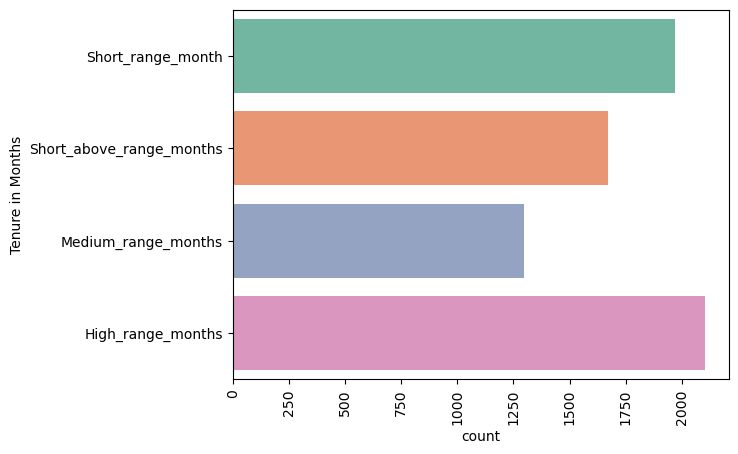

In [38]:
sb.countplot(y = ibdata_cut,hue=ibdata_cut,palette="Set2")
plt.xticks(rotation=90)
plt.show()

# Customer Tenure Distribution Analysis
## * The majority of customers belong to the High-tenure segment, indicating strong long-term customer retention.

## * A significant portion of customers also fall under the Short_month tenure category, suggesting a noticeable inflow of new customers.

## * The Medium tenure segment has comparatively lower representation, which may indicate a transition gap between new and long-term customers.

In [39]:
ibdata['Churn Category'].unique()

array(['Competitor', 'Dissatisfaction', 'Price', 'Other', 'Attitude', nan],
      dtype=object)

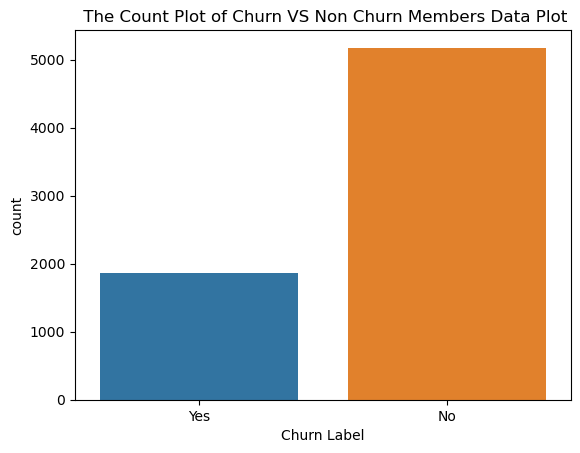

In [40]:
sb.countplot(x = "Churn Label",data = ibdata , hue = "Churn Label")
plt.title(" The Count Plot of Churn VS Non Churn Members Data Plot")
plt.show()

In [41]:
ibdata["Churn Label"].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [42]:
churn_rate = (ibdata["Churn Label"]== "Yes").astype(int).mean()
print(f" The Churn Rate of the IBM Telcom in 72 months is {churn_rate*100} Percent ")
print(f" The Retain Rate of the IBM Telcom in 72 months is {(1 - churn_rate)*100} Percent ")

 The Churn Rate of the IBM Telcom in 72 months is 26.536987079369588 Percent 
 The Retain Rate of the IBM Telcom in 72 months is 73.4630129206304 Percent 


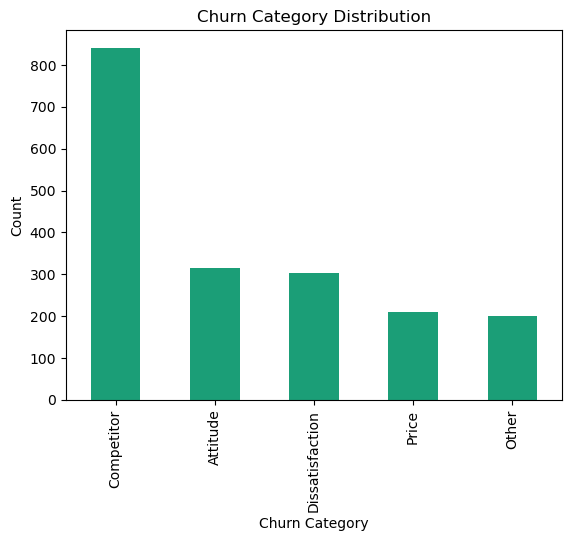

In [43]:
## Churn Category levels Plot Univariant

ibdata['Churn Category'].value_counts().plot(kind='bar',cmap="Dark2")
plt.xlabel("Churn Category")
plt.ylabel("Count")
plt.title("Churn Category Distribution")
plt.show()

## Competitive pressure is the leading churn driver, followed by service-related dissatisfaction and customer experience issues. 
## This indicates that both external market competition and internal service quality contribute significantly to customer attrition.

In [44]:
ibdata["tenure_cut"] = pd.cut(ibdata['Tenure in Months'],bins=[0, 10, 30, 50, 80],
                       labels=["Short_range_month", "Short_above_range_months", "Medium_range_months", "High_range_months"],
                       include_lowest=True)

In [45]:
# Filter only churned customers 
churned = ibdata[ibdata["Churn Label"] == "Yes"]  

# Group by Tenure bucket and Churn Category
prob_table = (churned.groupby("tenure_cut")["Churn Category"].value_counts(normalize=True))

print(prob_table)


tenure_cut                Churn Category 
Short_range_month         Competitor         0.458678
                          Attitude           0.175620
                          Dissatisfaction    0.155992
                          Price              0.107438
                          Other              0.102273
Short_above_range_months  Competitor         0.455142
                          Dissatisfaction    0.179431
                          Attitude           0.155361
                          Price              0.107221
                          Other              0.102845
Medium_range_months       Competitor         0.402344
                          Attitude           0.164062
                          Dissatisfaction    0.160156
                          Other              0.152344
                          Price              0.121094
High_range_months         Competitor         0.457447
                          Attitude           0.164894
                          Dissatisfactio

C:\Users\AKILAN M\AppData\Local\Temp\ipykernel_17604\686256972.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prob_table = (churned.groupby("tenure_cut")["Churn Category"].value_counts(normalize=True))


# Competitive Pressure is the Primary Driver
## The primary churn driver is competitive pressure, indicating market positioning challenges rather than purely internal pricing issues. 

## However, service-related dissatisfaction also contributes significantly.

## A combined strategy of competitive benchmarking and service quality enhancement is required to reduce churn

In [46]:
tenure_cut_table = pd.crosstab(ibdata["tenure_cut"],ibdata["Churn Label"],normalize="index")
print(tenure_cut_table)

Churn Label                     No       Yes
tenure_cut                                  
Short_range_month         0.508629  0.491371
Short_above_range_months  0.726511  0.273489
Medium_range_months       0.802621  0.197379
High_range_months         0.910689  0.089311


In [47]:
Life_time_avg = 1 / tenure_cut_table["Yes"]
print(Life_time_avg)

tenure_cut
Short_range_month            2.035124
Short_above_range_months     3.656455
Medium_range_months          5.066406
High_range_months           11.196809
Name: Yes, dtype: float64


# Using churn probability per tenure segment, 
## I estimated expected customer lifetime as inverse of churn rate.
## Customers with higher tenure show significantly longer expected lifetime, indicating lower churn risk.

In [48]:
ibdata["Churn Score"].unique()

array([91, 69, 81, 88, 67, 95, 76, 85, 86, 65, 96, 84, 80, 73, 83, 90, 89,
       87, 82, 74, 66, 92, 72, 70, 94, 68, 75, 93, 77, 79, 71, 78, 38, 40,
       52, 25, 59, 21, 55, 60, 28,  8,  7, 50, 36, 23, 41, 34, 26, 56, 44,
       30, 62, 24, 47, 22, 32, 64, 27, 29, 54, 39, 45, 33, 58, 35, 20, 31,
       61, 49, 37, 63, 48, 57, 42, 53, 46, 43, 51,  9,  5])

In [49]:
charges =ibdata[['Monthly Charge',
               'Total Charges',
               'Total Refunds',
               'Total Extra Data Charges',
               'Total Long Distance Charges',
               'Total Revenue',
               'Satisfaction Score']]

In [50]:
charges.head()

,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score
0,39.65,39.65,0.00,20,0.00,59.65,3
1,80.65,633.30,0.00,0,390.80,1024.10,3
2,95.45,1752.55,45.61,0,203.94,1910.88,2
3,98.50,2514.50,13.43,0,494.00,2995.07,2
4,76.50,2868.15,0.00,0,234.21,3102.36,2


In [51]:
## Total Revenue of all customer 
print(f" The minimum revenue by the customer in Data is {ibdata['Total Revenue'].min()} USD ")
print(f" The minimum revenue by the customer in Data is {ibdata['Total Revenue'].max()} USD")
print(f" The Total revenue by the customer in Data is {ibdata['Total Revenue'].sum():.2f} USD")

 The minimum revenue by the customer in Data is 21.36 USD 
 The minimum revenue by the customer in Data is 11979.34 USD
 The Total revenue by the customer in Data is 21371131.69 USD


In [52]:
## Average of Revenue per User Total
ARPU = ibdata["Total Revenue"].sum() / len(ibdata)
print(f" The Average of Revenue across customers is {ARPU:.2f} USD ")

 The Average of Revenue across customers is 3034.38 USD 


In [53]:
## Monthly ARPU 
monthly_arpu = ibdata["Monthly Charge"].mean()
print(f" The Monthly ARPU value of customers is {monthly_arpu:.2f} USD")

 The Monthly ARPU value of customers is 64.76 USD


In [54]:
## Revenue per customer per month
monthly_arpu_tenure = ibdata["Total Revenue"].sum() / ibdata["Tenure in Months"].sum()
print(f" Revenue per customer per month {monthly_arpu_tenure:.2f} USD")

 Revenue per customer per month 93.69 USD


In [55]:
## Customer Lifetime Value (CLV)

clv = monthly_arpu_tenure / churn_rate
print(f"The Customer Lifetime Value is {clv:.2f}")

The Customer Lifetime Value is 353.06


In [56]:
Life_time = clv / monthly_arpu_tenure
print(f"The Avereage Lifetime of the Customer is {Life_time:.1f} Months")

The Avereage Lifetime of the Customer is 3.8 Months


## The minimum revenue by the customer in Data is 21.36 USD 
## The minimum revenue by the customer in Data is 11979.34 USD
## The Total revenue by the customers in Data is 21371131.69 USD

## The Average of Revenue across customers is 3034.38 USD
## The Monthly ARPU value of customers is 64.76 USD

## Revenue per customer per month 93.69 USD
## The Customer Lifetime Value is 353.06
## The Avereage Lifetime of the Customer is 3.8 Months

C:\Users\AKILAN M\AppData\Local\Temp\ipykernel_17604\2730940715.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


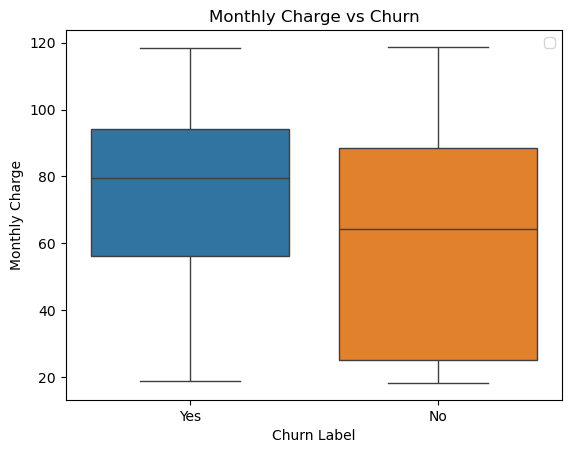

In [57]:
sb.boxplot(x="Churn Label", y="Monthly Charge", data= ibdata, hue ="Churn Label")
plt.title("Monthly Charge vs Churn")
plt.legend()
plt.show()

## Churned Customers are paying higher monthly charges then non Churn Persond on Average
## Churned Customer are Paying higher mpnthly on  average (Price Sensitive Problem)
## Spread In Non Churn group has wider Range, but in Churn Yes group is slightly more concentrated in Higher Range

In [58]:
ibdata['Total Revenue'].min()

21.36

In [59]:
bins1 = [0, 1000, 3000, 6000, 9000, 12000]
labels1 = ["Very Low", "Low", "Medium", "High", "Very High"]

ibdata["Revenue Bucket"] = pd.cut(ibdata["Total Revenue"],bins=bins1,labels=labels1)

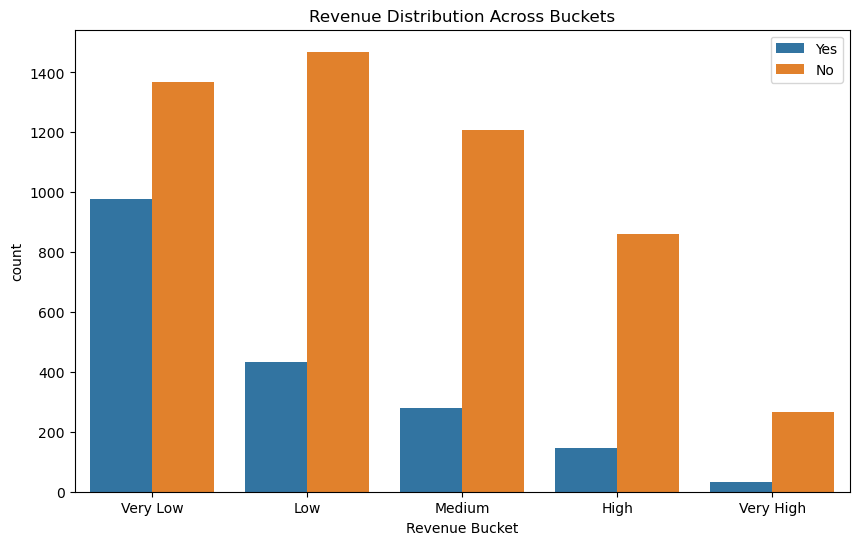

In [60]:
plt.figure(figsize=(10,6))
sb.countplot(x="Revenue Bucket", data=ibdata, hue ="Churn Label")
plt.title("Revenue Distribution Across Buckets")
plt.legend()
plt.show()

## Revenue Lower customers have the large chance of Churn comparitive
## Churn shows inverse relationship to Revenue



## Customers age distribution

In [61]:
print(f"The Minimum Age of Customer is {ibdata['Age'].min()}")
print(f"The Minimum Age of Customer is {ibdata['Age'].max()}")

The Minimum Age of Customer is 19
The Minimum Age of Customer is 80


In [62]:
binsage = [19, 30, 40, 50, 60, 80]
labelsage = ["19-30", "31-40", "41-50", "51-60", "61-80"]

In [63]:
ibdata["Age Group"] = pd.cut(ibdata["Age"],bins= binsage,labels=labelsage,include_lowest=True)

In [64]:
print(ibdata["Age Group"].value_counts())

Age Group
61-80    1662
19-30    1529
41-50    1312
31-40    1288
51-60    1252
Name: count, dtype: int64


In [65]:
Age_summary = ibdata.groupby("Age Group")["Total Revenue"].agg(["count", "sum", "mean", "median"])

print(Age_summary)

           count         sum         mean    median
Age Group                                          
19-30       1529  4558053.76  2981.068515  2070.180
31-40       1288  3779490.80  2934.387267  1932.865
41-50       1312  3836067.57  2923.831989  1970.755
51-60       1252  3649419.85  2914.872085  1984.640
61-80       1662  5548099.71  3338.206805  2534.540


C:\Users\AKILAN M\AppData\Local\Temp\ipykernel_17604\2185050539.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Age_summary = ibdata.groupby("Age Group")["Total Revenue"].agg(["count", "sum", "mean", "median"])


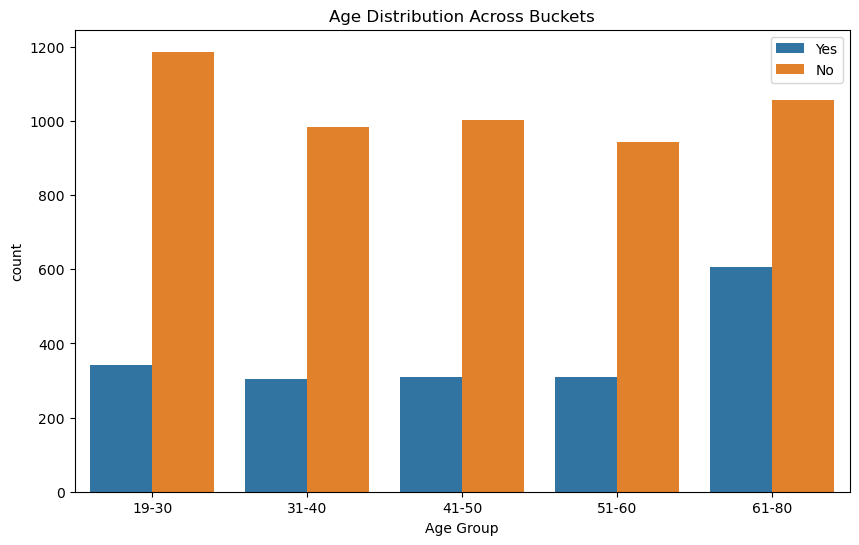

In [66]:
plt.figure(figsize=(10,6))
sb.countplot(x= "Age Group", data=ibdata, hue ="Churn Label")
plt.title("Age Distribution Across Buckets")
plt.legend()
plt.show()

## The analysis shows that churn behavior varies across age groups. 
## Customers aged 61–80 exhibit the highest churn counts, suggesting that older customers may disengage due to usability or service complexity. Younger customers aged 19–30 also display relatively high churn, likely driven by price sensitivity and competitor offers. In contrast, middle-aged customers demonstrate more stable retention patterns.

In [67]:
Age_churn_analysis = ibdata.groupby(["Age Group", "Churn Label"])["Total Revenue"].mean()

print(Age_churn_analysis)

Age Group  Churn Label
19-30      No             3284.935350
           Yes            1926.419591
31-40      No             3282.425279
           Yes            1802.976568
41-50      No             3278.193589
           Yes            1773.590291
51-60      No             3250.476999
           Yes            1890.679741
61-80      No             3978.254479
           Yes            2222.876205
Name: Total Revenue, dtype: float64


C:\Users\AKILAN M\AppData\Local\Temp\ipykernel_17604\265595323.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Age_churn_analysis = ibdata.groupby(["Age Group", "Churn Label"])["Total Revenue"].mean()


## Older customers contribute the highest revenue.
## Losing older customers is more costly.

## Revenue generation is stable in middle-age groups.
## Churn impact is consistent here

# Biggest revenue loss due to churn happens in age group between 61–80.

In [68]:
## Age Groups with Marietal Stauts
Age_mar = ibdata.groupby("Age Group")["Married"].value_counts()
pd.DataFrame(Age_mar)

C:\Users\AKILAN M\AppData\Local\Temp\ipykernel_17604\3633444343.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Age_mar = ibdata.groupby("Age Group")["Married"].value_counts()


count
Age Group Married       
19-30     No         772
          Yes        757
31-40     No         653
          Yes        635
41-50     No         704
          Yes        608
51-60     No         660
          Yes        592
61-80     No         852
          Yes        810

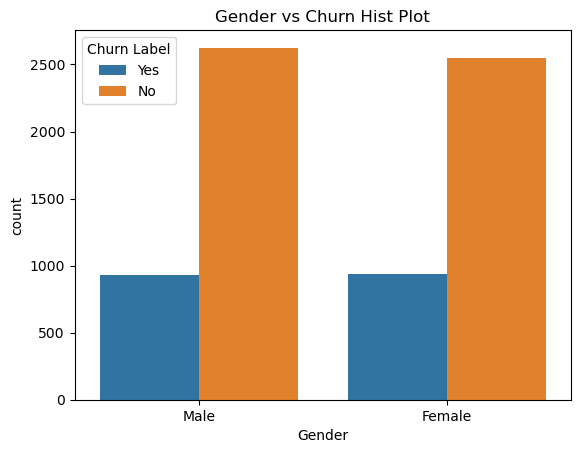

In [69]:
## Gender wise churn analysis

sb.countplot(x="Gender", data=ibdata, hue ="Churn Label")
plt.title("Gender vs Churn Hist Plot")
plt.show()

# From Plot Both Male and Female have Similar Number of Churn
## No major visual gap
## Both both genders seem equally likely to churn

In [70]:
Age_gendby = ibdata.groupby("Age Group", observed=True)["Gender"].value_counts()

In [71]:
pd.DataFrame(Age_gendby)

count
Age Group Gender       
19-30     Female    770
          Male      759
31-40     Male      675
          Female    613
41-50     Female    656
          Male      656
51-60     Female    628
          Male      624
61-80     Male      841
          Female    821

In [72]:
from scipy.stats import chi2_contingency

In [73]:
agegendt = pd.crosstab(ibdata["Gender"],ibdata["Churn Label"])

In [74]:
print("Customer Distribution by Gender and Churn Status")

agegendt

Customer Distribution by Gender and Churn Status


Churn Label,No,Yes
Gender,,
Female,2549,939
Male,2625,930


In [75]:
from scipy.stats import chi2_contingency
import pandas as pd

chi2, p, dof, expected = chi2_contingency(pd.crosstab(ibdata['Gender'], ibdata['Churn Label']))

print(f"Chi-Square Statistic : {chi2:.4f}")
print(f"P-Value             : {p:.4f}")
print(f"Degrees of Freedom  : {dof}")
print("\nExpected Frequencies:")
print(pd.DataFrame(expected))

Chi-Square Statistic : 0.4841
P-Value             : 0.4866
Degrees of Freedom  : 1

Expected Frequencies:
             0           1
0  2562.389891  925.610109
1  2611.610109  943.389891


## Gender does not significantly influence churn

In [76]:
Age_unstack = Age_gendby.unstack()

In [77]:
Age_unstack

Gender,Female,Male
Age Group,,
19-30,770,759
31-40,613,675
41-50,656,656
51-60,628,624
61-80,821,841


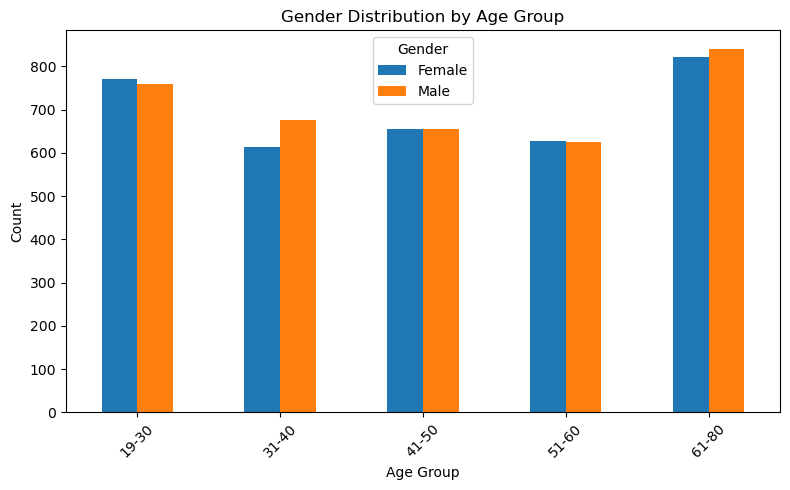

In [78]:
Age_unstack.plot(kind="bar", figsize=(8,5))

plt.title("Gender Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Gender")
plt.tight_layout()
plt.show()


## Customer Base is Highest in two Age groups 19-30 and 61-80
## These two age groups have the highest number of customers
## Young adults and seniors form a major customer base 

# Telephone Churn Insights

In [79]:
ibdata["Multiple Lines"].unique()

array(['No', 'Yes'], dtype=object)

In [80]:
ibdata["Multiple Lines"] = ibdata["Multiple Lines"].map({"Yes":1, "No":0})

In [81]:
ibdata[["Multiple Lines","Churn Binary"]].dtypes

Multiple Lines    int64
Churn Binary      int64
dtype: object

In [82]:
ibdata["Multiple Lines"].value_counts()

Multiple Lines
0    4072
1    2971
Name: count, dtype: int64

In [83]:
mulcon_data = ibdata.groupby("Internet Type")[["Multiple Lines","Churn Binary"]].mean().sort_values(by = "Churn Binary", ascending=False)
mulcon_data

,Multiple Lines,Churn Binary
Internet Type,,
Fiber Optic,0.626030,0.407249
Cable,0.290361,0.256627
DSL,0.295400,0.185835


## Fiber Optic customers exhibit the highest churn rate (40.7%) despite having the highest adoption of multiple lines (62.6%),
## Indicating that internet type plays a stronger role in churn than line bundling

# Internet Insights

In [84]:
Internet_service = ["Internet Service","Internet Type","Avg Monthly GB Download"]

<Figure size 200x400 with 0 Axes>

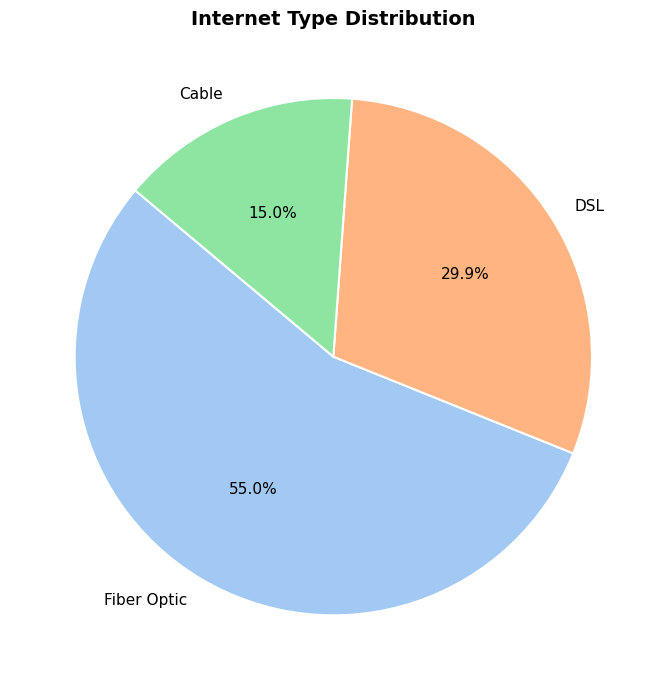

In [85]:
plt.figure(figsize=(2,4))
counts = ibdata["Internet Type"].value_counts()
colors_IT = sb.color_palette("pastel")

plt.figure(figsize=(7,7))

plt.pie(counts,labels=counts.index, autopct='%1.1f%%',startangle=140,
    colors=colors_IT, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    textprops={'fontsize': 11})

plt.title("Internet Type Distribution", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## The relatively high percentage of non-internet users (21.7%) suggests:

## A potential cross-selling opportunity for broadband services.

## Pricing, accessibility, or customer awareness may be influencing adoption gaps.

## Fiber’s dominance reflects strong demand for high-speed services, which could influence future infrastructure investments.

In [86]:
app_data = ibdata.groupby("Internet Type")["Avg Monthly GB Download"].mean().sort_values(ascending=False)
app_data

Internet Type
Cable          27.872289
DSL            27.514528
Fiber Optic    25.008896
Name: Avg Monthly GB Download, dtype: float64

C:\Users\AKILAN M\AppData\Local\Temp\ipykernel_17604\4048654416.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x=app_data.index,y=app_data.values,palette="Set2")


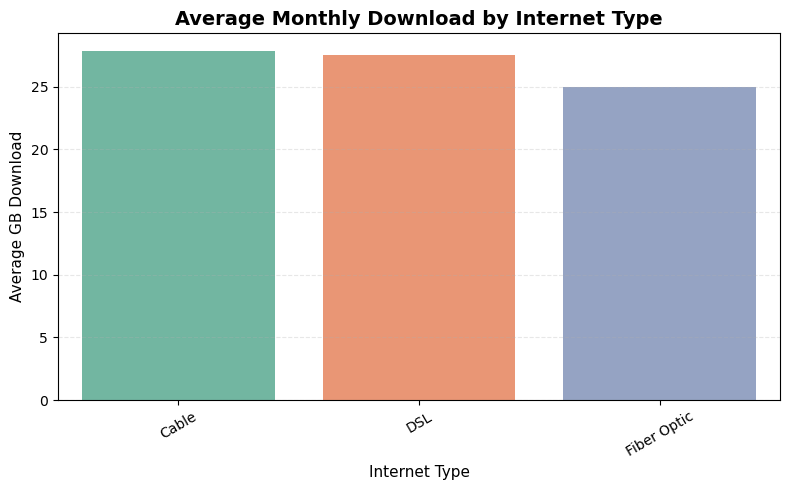

In [87]:
plt.figure(figsize=(8,5))
sb.barplot(x=app_data.index,y=app_data.values,palette="Set2")

plt.title("Average Monthly Download by Internet Type",fontsize=14, fontweight="bold")

plt.xlabel("Internet Type", fontsize=11)
plt.ylabel("Average GB Download", fontsize=11)

plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## Cable & DSL Users Download Slightly More
## Cable and DSL customers have higher average monthly downloads than Fiber users
## Fiber is usually faster, even they are not high 

In [88]:
Inter_churn = ibdata.groupby("Internet Type")[["Avg Monthly GB Download", "Churn Binary"]].mean().sort_values(by ="Churn Binary", ascending=False)

In [89]:
Inter_churn["Churn Binary"] = Inter_churn["Churn Binary"]*100

In [90]:
Inter_churn

,Avg Monthly GB Download,Churn Binary
Internet Type,,
Fiber Optic,25.008896,40.724876
Cable,27.872289,25.662651
DSL,27.514528,18.583535


## Fiber customers churn the most despite moderate usage
## Cable users consume the most data but churn moderately
## DSL users show lower churn despite similar data usage

In [91]:
Int_mnt = ibdata.groupby("Internet Type")[["Monthly Charge", "Churn Binary"]].mean().sort_values(by ="Churn Binary", ascending=False)

In [92]:
Int_mnt["Churn Binary"] = Int_mnt["Churn Binary"]*100

In [93]:
Int_mnt

,Monthly Charge,Churn Binary
Internet Type,,
Fiber Optic,91.532389,40.724876
Cable,60.277530,25.662651
DSL,58.183172,18.583535


## Fiber customers are likely price-sensitive or dissatisfied despite premium pricing.
## Overpricing in the fifer segment makes more customer Churn chance
## DSL Similar pricing to Cable , Lower churn (18%), this segment seems more satisfied.

In [94]:
Int_Tchg = ibdata.groupby("Internet Type")[["Total Charges","Tenure in Months","Churn Binary"]].mean().sort_values(by ="Churn Binary", ascending=False)

In [95]:
Int_Tchg["Churn Binary"] = Int_Tchg["Churn Binary"]*100

In [96]:
Int_Tchg 

,Total Charges,Tenure in Months,Churn Binary
Internet Type,,,
Fiber Optic,3229.348072,33.142998,40.724876
Cable,2086.089096,31.971084,25.662651
DSL,2128.181265,32.869249,18.583535


## Fiber customers have comparable tenure to other segments, yet exhibit significantly higher churn, 
## Indicating dissatisfaction over time rather than early lifecycle churn

In [97]:
ibdata["GB_Group"] = pd.qcut(ibdata["Avg Monthly GB Download"], q=4, 
    labels=["Low", "Medium", "High", "Very High"])

In [98]:
internet_users = ibdata[ibdata["Internet Service"] == "Yes"]

pd.crosstab(
    internet_users["GB_Group"],internet_users["Churn Label"],normalize="index")

Churn Label,No,Yes
GB_Group,,
Low,0.630081,0.369919
Medium,0.651125,0.348875
High,0.673043,0.326957
Very High,0.732143,0.267857


## As GB usage increases churn decreases.
## Heavy users churn less. Light users churn more.
## Low Usage (36.9% churn)
## Not fully engaged Easy to switch Possibly price sensitive
## Very High Usage (26.8% churn)
## Highly dependent on service Harder to switch Internet is essential More sticky customers


In [99]:
ibdata["AddOn_Count"] = (
    (ibdata["Online Security"] == "Yes").astype(int) +
    (ibdata["Online Backup"] == "Yes").astype(int) +
    (ibdata["Device Protection Plan"] == "Yes").astype(int) +
    (ibdata["Premium Tech Support"] == "Yes").astype(int))

In [100]:
pd.crosstab(ibdata["AddOn_Count"],ibdata["Churn Label"],normalize="index")

Churn Label,No,Yes
AddOn_Count,,
0,0.702470,0.297530
1,0.611452,0.388548
2,0.762391,0.237609
3,0.875664,0.124336
4,0.946809,0.053191


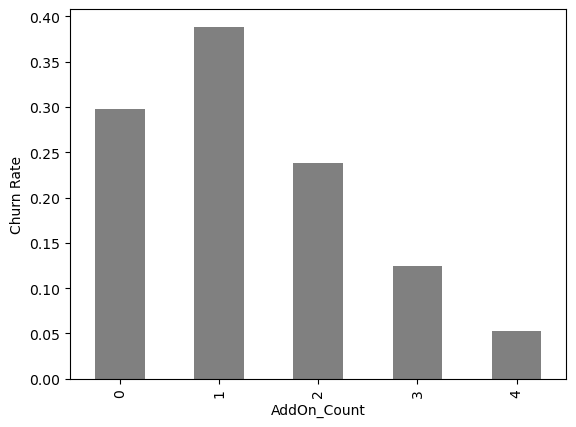

In [101]:
churn_rate = pd.crosstab(
    ibdata["AddOn_Count"],
    ibdata["Churn Label"],
    normalize="index")["Yes"]

churn_rate.plot(kind="bar",color ="grey")
plt.ylabel("Churn Rate")
plt.title("")
plt.show()

## Customers with only 1 add-on have the highest churn Churn rate is of 39%
## Customers who use only one extra service are most likely to leave.
## Possible reason: They are not fully engaged with the ecosystem, Easy to switch to competitors.

In [102]:
pd.crosstab(
    [ibdata["Internet Service"], ibdata["AddOn_Count"]],
    ibdata["Churn Label"],
    normalize="index")

Churn Label                         No       Yes
Internet Service AddOn_Count                    
No               0            0.925950  0.074050
Yes              0            0.433307  0.566693
                 1            0.611452  0.388548
                 2            0.762391  0.237609
                 3            0.875664  0.124336
                 4            0.946809  0.053191

# City-wise Revenue Analysis Demographic Insights

In [103]:
city_counts = ibdata["City"].value_counts()
rare_cities = city_counts[city_counts < 30].index
ibdata["City_Grouped"] = ibdata["City"].replace(rare_cities, "Other")

In [104]:
## City Counts
city_counts

City
Los Angeles               293
San Diego                 285
San Jose                  112
Sacramento                108
San Francisco             104
Fresno                     61
Long Beach                 60
Oakland                    52
Escondido                  51
Stockton                   44
Fallbrook                  43
Glendale                   40
Bakersfield                39
Temecula                   38
Berkeley                   32
Riverside                  32
Whittier                   30
Pasadena                   30
Modesto                    28
Santa Barbara              28
San Bernardino             28
Anaheim                    28
Irvine                     28
Torrance                   25
Inglewood                  25
Burbank                    25
Santa Monica               25
Santa Ana                  24
Santa Rosa                 24
Chula Vista                22
Rancho Cucamonga           20
Salinas                    20
Orange                     20
Garde

In [105]:
top_cities = []
for i in city_counts.index:
    if i in rare_cities:
        continue
    else:
        top_cities.append(i)

In [106]:
top_cit_sorted = sorted(top_cities) 

In [107]:
## TOP 20 Counted Cities
top_cit_sorted

['Bakersfield',
 'Berkeley',
 'Escondido',
 'Fallbrook',
 'Fresno',
 'Glendale',
 'Long Beach',
 'Los Angeles',
 'Oakland',
 'Pasadena',
 'Riverside',
 'Sacramento',
 'San Diego',
 'San Francisco',
 'San Jose',
 'Stockton',
 'Temecula',
 'Whittier']

C:\Users\AKILAN M\AppData\Local\Temp\ipykernel_17604\2303463881.py:6: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(ibdata["Longitude"],ibdata["Latitude"],marker='x',alpha=0.5,s =20,edgecolors='none',c=ibdata["Churn Label"].map({"Yes": "#c44e52", "No": "#4c72b0"}))


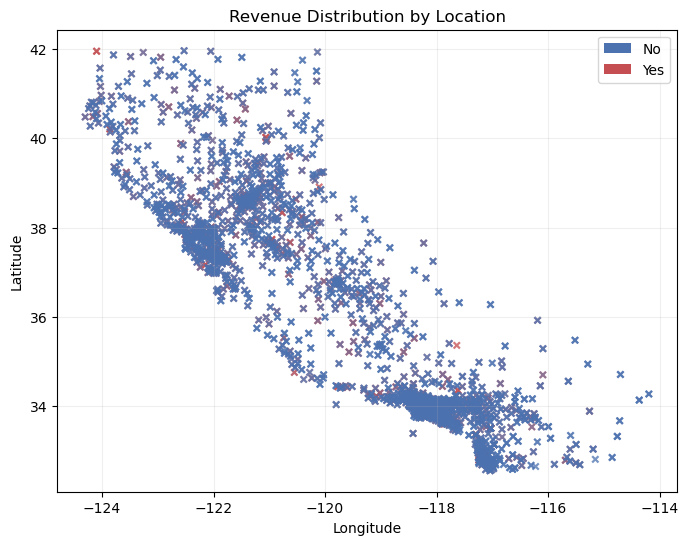

In [108]:
legend_elements = [Patch(facecolor="#4c72b0", label="No"),Patch(facecolor="#c44e52", label="Yes")]


plt.figure(figsize=(8,6))
plt.grid(alpha=0.2)
plt.scatter(ibdata["Longitude"],ibdata["Latitude"],marker='x',alpha=0.5,s =20,edgecolors='none',c=ibdata["Churn Label"].map({"Yes": "#c44e52", "No": "#4c72b0"}))
plt.legend(handles=legend_elements)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Revenue Distribution by Location")
plt.show()

## Churn here with revenue is not strongly driven by geographical location alone
## Customer distribution shows strong clustering in major metropolitan regions, particularly Southern California and the Bay Area

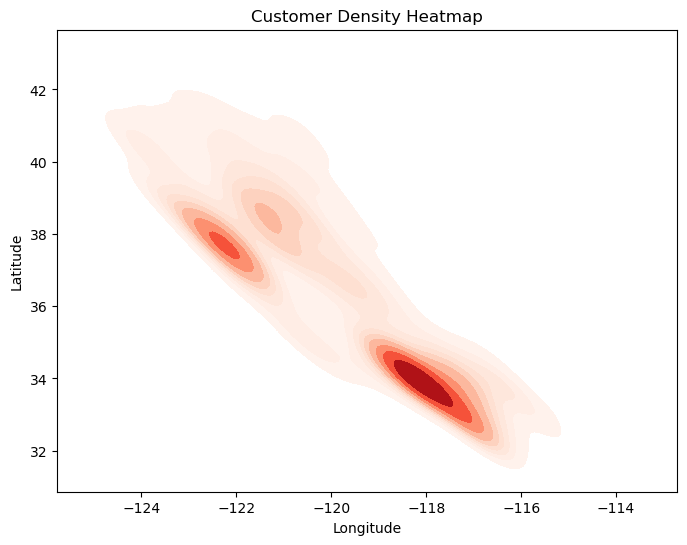

In [109]:
plt.figure(figsize=(8,6))

sb.kdeplot(
    x=ibdata["Longitude"],
    y=ibdata["Latitude"],
    fill=True,
    cmap="Reds")

plt.title("Customer Density Heatmap")
plt.show()

## Customer concentration is highest in the Southern California region (approx. 32–34° latitude and -118° longitude) 
## Indicating a strong market presence in this metropolitan cluster

In [110]:
gap = ibdata.groupby(["Age Group", "Churn Label"])["Total Revenue"].mean().unstack()

gap["Revenue Loss"] = gap["No"] - gap["Yes"]
print(gap)

Churn Label           No          Yes  Revenue Loss
Age Group                                          
19-30        3284.935350  1926.419591   1358.515759
31-40        3282.425279  1802.976568   1479.448712
41-50        3278.193589  1773.590291   1504.603298
51-60        3250.476999  1890.679741   1359.797258
61-80        3978.254479  2222.876205   1755.378275


C:\Users\AKILAN M\AppData\Local\Temp\ipykernel_17604\1102747422.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gap = ibdata.groupby(["Age Group", "Churn Label"])["Total Revenue"].mean().unstack()


In [111]:
country_rev = ibdata.groupby("City")["Total Revenue"].sum().reset_index()


In [112]:

for i, j in zip(country_rev["City"], country_rev["Total Revenue"]):
    print(f"The Country {i} shows Total Revenue of {j:.2f} USD")

The Country Acampo shows Total Revenue of 18107.96 USD
The Country Acton shows Total Revenue of 12156.36 USD
The Country Adelanto shows Total Revenue of 18235.49 USD
The Country Adin shows Total Revenue of 5539.38 USD
The Country Agoura Hills shows Total Revenue of 10641.88 USD
The Country Aguanga shows Total Revenue of 10033.52 USD
The Country Ahwahnee shows Total Revenue of 9336.36 USD
The Country Alameda shows Total Revenue of 14092.66 USD
The Country Alamo shows Total Revenue of 30424.46 USD
The Country Albany shows Total Revenue of 15788.32 USD
The Country Albion shows Total Revenue of 8536.12 USD
The Country Alderpoint shows Total Revenue of 15541.53 USD
The Country Alhambra shows Total Revenue of 9292.61 USD
The Country Aliso Viejo shows Total Revenue of 26807.83 USD
The Country Alleghany shows Total Revenue of 4328.21 USD
The Country Alpaugh shows Total Revenue of 11860.65 USD
The Country Alpine shows Total Revenue of 11379.36 USD
The Country Alta shows Total Revenue of 9490.16

In [113]:
print(f"The number of Customers in the city {ibdata['City'].value_counts()}")


The number of Customers in the city City
Los Angeles               293
San Diego                 285
San Jose                  112
Sacramento                108
San Francisco             104
Fresno                     61
Long Beach                 60
Oakland                    52
Escondido                  51
Stockton                   44
Fallbrook                  43
Glendale                   40
Bakersfield                39
Temecula                   38
Berkeley                   32
Riverside                  32
Whittier                   30
Pasadena                   30
Modesto                    28
Santa Barbara              28
San Bernardino             28
Anaheim                    28
Irvine                     28
Torrance                   25
Inglewood                  25
Burbank                    25
Santa Monica               25
Santa Ana                  24
Santa Rosa                 24
Chula Vista                22
Rancho Cucamonga           20
Salinas                    20

In [114]:
from sklearn.cluster import KMeans

# Clustering Customers Based on Demographic Location

In [115]:
coords = ibdata[["Latitude", "Longitude"]]


In [116]:
kmeans = KMeans(n_clusters=3,n_init='auto', random_state=42)


In [117]:
ibdata["cluster"] = kmeans.fit_predict(coords)

In [118]:
centers = kmeans.cluster_centers_
print(centers)

[[  36.4442715  -119.97897106]
 [  38.76763866 -121.97473581]
 [  33.80726866 -117.69098521]]


In [119]:
ibdata["Customer Status"].unique()

array(['Churned', 'Stayed', 'Joined'], dtype=object)

In [120]:
ibdata["Customer Status"].value_counts(normalize=True) * 100

Customer Status
Stayed     67.016896
Churned    26.536987
Joined      6.446117
Name: proportion, dtype: float64

In [121]:
status_table = pd.crosstab(ibdata["Age Group"], ibdata["Customer Status"])
status_table

Customer Status,Churned,Joined,Stayed
Age Group,,,
19-30,342,105,1082
31-40,303,110,875
41-50,309,97,906
51-60,309,79,864
61-80,606,63,993


<Figure size 900x600 with 0 Axes>

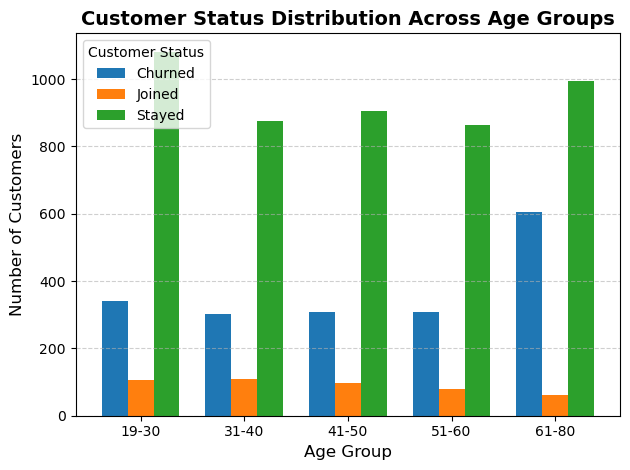

In [122]:
plt.figure(figsize=(9,6))

ax = status_table.plot(
    kind="bar",
    width=0.75
)

plt.title("Customer Status Distribution Across Age Groups", fontsize=14, weight='bold')
plt.xlabel("Age Group", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

plt.xticks(rotation=0)
plt.legend(title="Customer Status")

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Young customers are dynamic and price-sensitive.
## 31–40 & 41–50 (Middle Age) Stayed is strong Joined is moderate 
## Churn is lower compared to young (Working professionals, Family user More contract-bound)
## 51–60 Similar stability Low churn Moderate joining Stable and predictable group.
## 61–80 (Senior Segment) High Stayed High Joined Very low churn Once acquired, they rarely leave.


In [123]:
import matplotlib.ticker as mtick

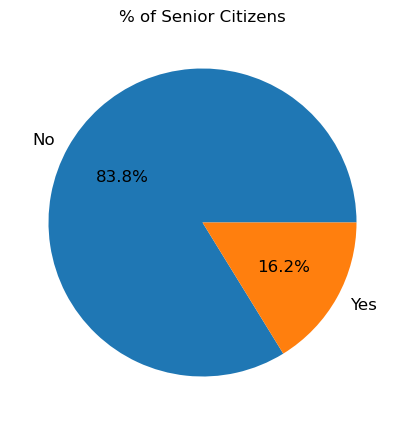

In [124]:
fig, ax = plt.subplots(figsize=(5,5))

(ibdata['Senior Citizen'].value_counts(normalize=True) * 100).plot.pie(autopct='%.1f%%',labels=['No', 'Yes'],fontsize=12,ax=ax)

ax.set_ylabel('')
ax.set_title('% of Senior Citizens', fontsize=12)

plt.show()


## The dataset is heavily skewed toward non-senior customers, who constitute approximately 84% of the customer base, while senior citizens represent only 16%.

In [125]:
pd.crosstab(ibdata["Senior Citizen"],ibdata["Churn Label"],normalize="index")

Churn Label,No,Yes
Senior Citizen,,
No,0.763938,0.236062
Yes,0.583187,0.416813


## Non-senior customers churn at 23.6%
## Senior citizens churn at 41.7%
## Seniors churn almost 18 percentage points higher.

## Even though seniors are only 16% of the dataset:
## They are significantly more likely to churn.
## They are a high-risk segment.
## Retention strategy should treat them separately

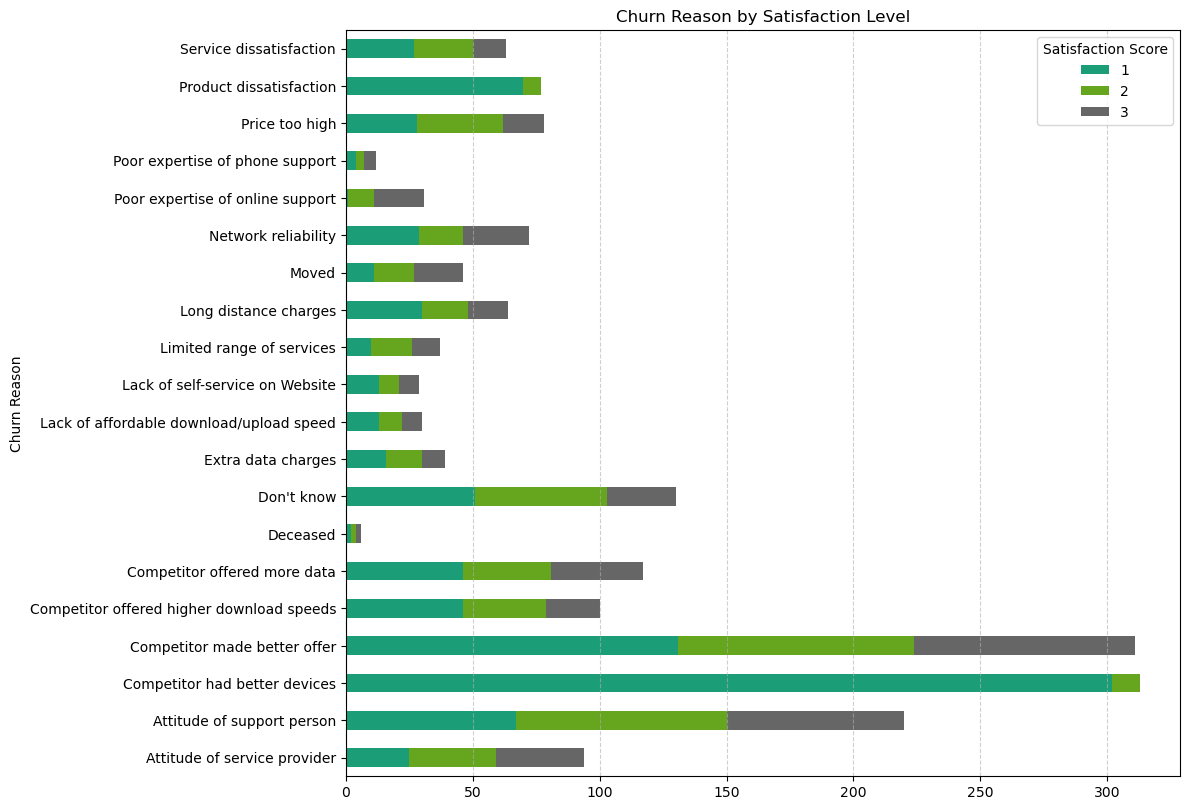

In [126]:
ct = pd.crosstab(ibdata["Churn Reason"],ibdata["Satisfaction Score"])
ct.plot(kind="barh",stacked=True,figsize=(12,8),cmap="Dark2")
plt.grid(axis='x', linestyle='--', alpha=0.6)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.title("Churn Reason by Satisfaction Level")
plt.show()

## Biggest Churn Driver: Competitor Offers 
## Competitor had better devices Competitor made better offer Competitor offered more data / higher speeds
## Many customers leave not only because of dissatisfaction, but because competitors provide better value.
## Customers compare devices, data plans, and speed
## Service Issues with Service dissatisfaction Network reliability  Long distance charges Download/upload speed issues
## Customers with low satisfaction scores (1) mostly churn due to service problems.
## Pricing is a Major Factor Customers with low satisfaction levels often cite this
## Customers feel they pay more than the value received
## Customer Support Experience Matters Attitude of support person Attitude of service provider
## Lack of expertise of support Poor support experience contributes to churn.
## Minor reasons include: Moved Deceased Don't know
## These are natural churn factors that companies cannot control.

In [127]:
## Satisfaction Score Grouping churn vs non Churn
sat_chu = ibdata.groupby("Satisfaction Score")["Churn Label"].value_counts()
sat_chu

Satisfaction Score  Churn Label
1                   Yes             922
2                   Yes             518
3                   No             2236
                    Yes             429
4                   No             1789
5                   No             1149
Name: count, dtype: int64

In [128]:
sat_chu = sat_chu.reset_index()

In [129]:
sat_chu

,Satisfaction Score,Churn Label,count
0,1,Yes,922
1,2,Yes,518
2,3,No,2236
3,3,Yes,429
4,4,No,1789
5,5,No,1149


## Customers with Satisfaction Score of 1 or 2 show only churned customers (Yes) in the dataset.
## This indicates that customers with very poor satisfaction are extremely likely to churn, making satisfaction score a strong churn indicator
## Satisfaction Score 3: Moderate Satisfaction Shows Mixed Behavior Churn 429 and Non churn 2236, this group may leave if better alternatives are available. 
## Higher satisfaction scores are strongly associated with customer retention, showing that satisfied customers are more loyal.

C:\Users\AKILAN M\AppData\Local\Temp\ipykernel_17604\812063385.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x="Satisfaction Score", y="Churn Label", data=ibdata,palette="Set2" )


<Axes: xlabel='Satisfaction Score', ylabel='Churn Label'>

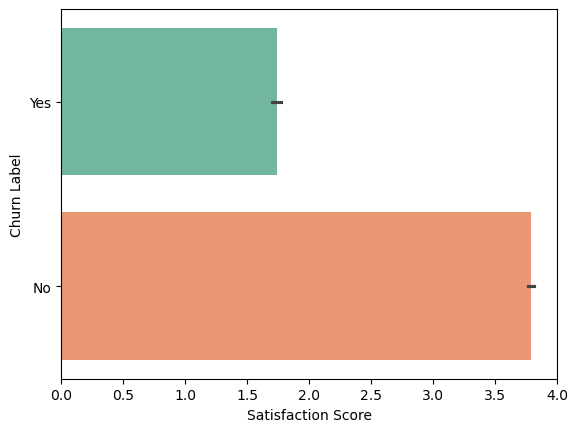

In [130]:
sb.barplot(x="Satisfaction Score", y="Churn Label", data=ibdata,palette="Set2" )

## Customers who churn tend to have lower satisfaction scores (around 1–2 on average), while customers who remain with the company generally have higher satisfaction scores (around 3.5–4 or above).
## This clear difference indicates that customer satisfaction is strongly associated with churn behavior, making it an important feature for identifying customers at risk of leaving.

# Account Metrics Impact on Customer Churn

In [131]:
def numerical_distribution(feature):
    fig = plt.figure(figsize=(15,10))
    plt.subplot(2,1,1)
    ax = sb.kdeplot(ibdata[feature], color = 'g',shade = True)
    title_str = feature + " Distribution"
    plt.title(title_str)
    plt.subplot(2,1,2)
    ax = sb.kdeplot(ibdata.loc[(ibdata['Churn Binary']==1),feature], color = 'r', shade = True, label='Chrun')

    ax = sb.kdeplot(ibdata.loc[(ibdata['Churn Binary']==0) ,feature], color = 'b', shade = True, label='No chrun')
    title_str = feature + " Distribution: Churn vs No churn"
    plt.title(title_str)
    plt.legend() 
    plt.show()

C:\Users\AKILAN M\AppData\Local\Temp\ipykernel_17604\3270271423.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  ax = sb.kdeplot(ibdata[feature], color = 'g',shade = True)
C:\Users\AKILAN M\AppData\Local\Temp\ipykernel_17604\3270271423.py:8: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  ax = sb.kdeplot(ibdata.loc[(ibdata['Churn Binary']==1),feature], color = 'r', shade = True, label='Chrun')
C:\Users\AKILAN M\AppData\Local\Temp\ipykernel_17604\3270271423.py:10: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  ax = sb.kdeplot(ibdata.loc[(ibdata['Churn Binary']==0) ,feature], color = 'b', shade = True, label='No chrun')


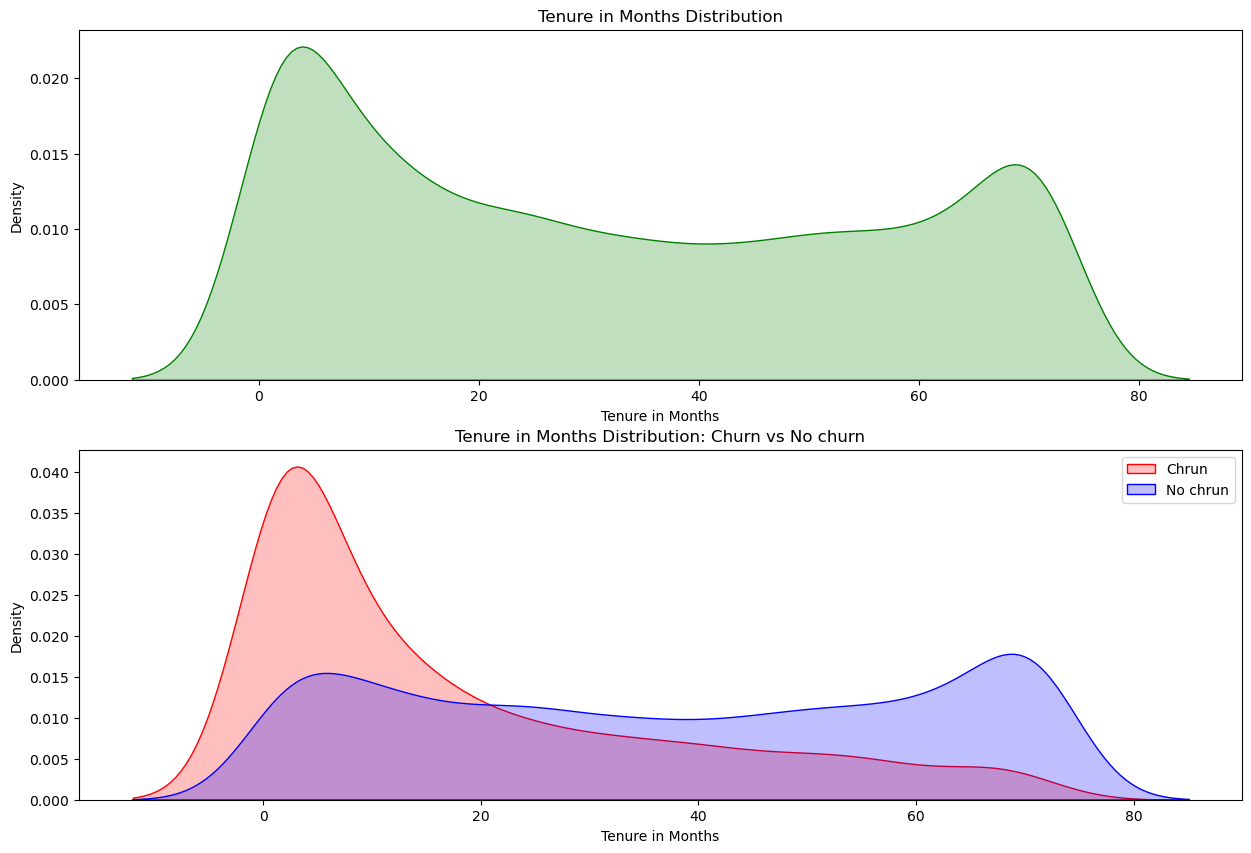

In [132]:
numerical_distribution("Tenure in Months")

# Churn Customers
## High density at low tenure (0-10 months)
## Density decreases as tenure increases, very few churn customers above 40-50 months
## Early Customers are more likely to churn 
# Non Churn Customers
## Spreads across entire tenure range
## Big conc at High tenure (60-80) months, Long term customers mostly stays

C:\Users\AKILAN M\AppData\Local\Temp\ipykernel_17604\3270271423.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  ax = sb.kdeplot(ibdata[feature], color = 'g',shade = True)
C:\Users\AKILAN M\AppData\Local\Temp\ipykernel_17604\3270271423.py:8: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  ax = sb.kdeplot(ibdata.loc[(ibdata['Churn Binary']==1),feature], color = 'r', shade = True, label='Chrun')
C:\Users\AKILAN M\AppData\Local\Temp\ipykernel_17604\3270271423.py:10: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  ax = sb.kdeplot(ibdata.loc[(ibdata['Churn Binary']==0) ,feature], color = 'b', shade = True, label='No chrun')


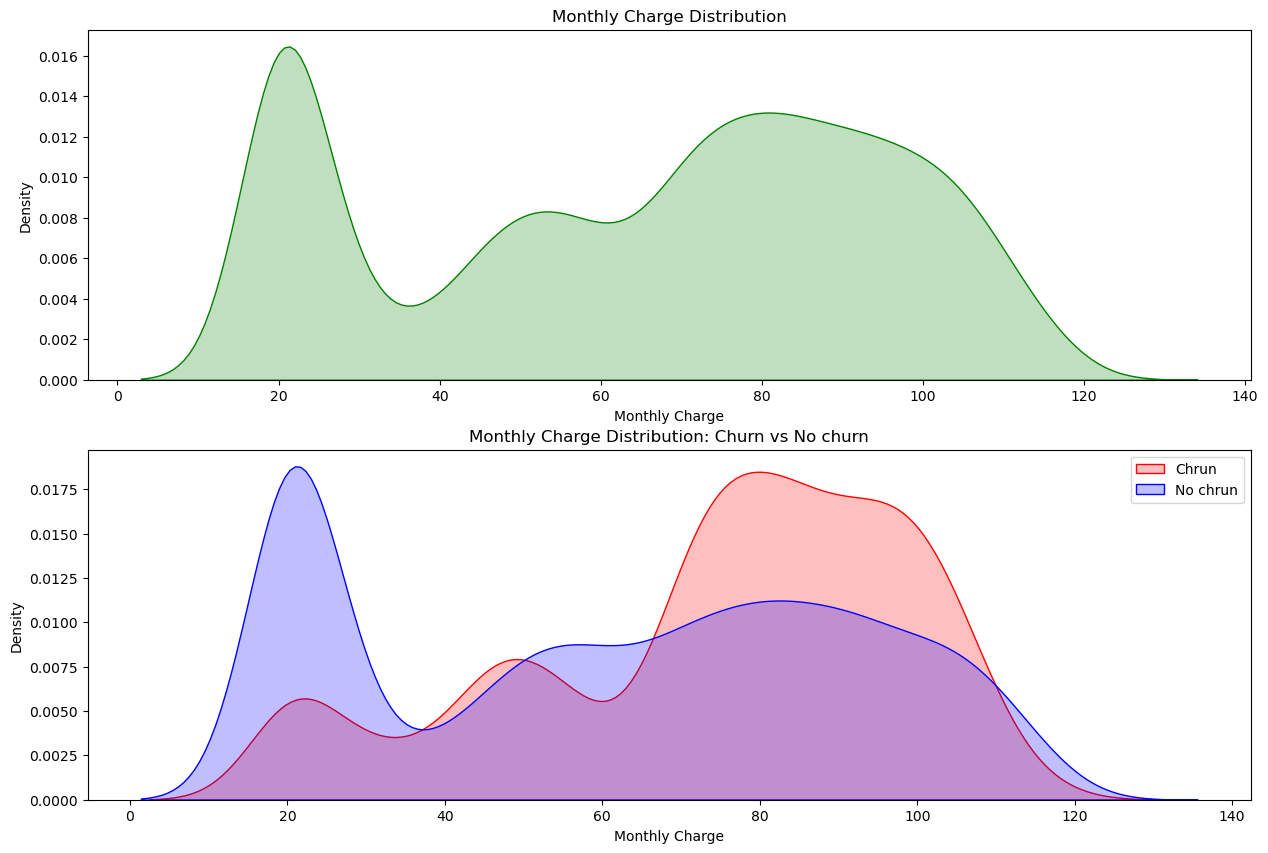

In [133]:
numerical_distribution("Monthly Charge")

## overall distribution of monthly charges for all customers
## The distribution is not uniform; it has multiple peaks. One peak appears around 20–30.
## Another large concentration is around 70–100. Very few customers have charges above 120.
## The company has multiple Offer plans. Customers fall mainly into two price groups:
## Low-cost plans might be Offer A (20–30) and Premium plans (70–100) Offer E

## Monthly charge is strongly related to churn.
## Customers paying lower prices tend to stay longer. Range (20-30)
## Churn risk starts increasing in this range.
## Customers with higher monthly charges are more likely to churn around (70-100)

In [134]:
ibdata.groupby("Offer")["Monthly Charge"].describe()

,count,mean,std,min,25%,50%,75%,max
Offer,,,,,,,,
Offer A,520.0,77.719519,31.113157,19.10,58.9875,85.30,104.4500,118.65
Offer B,824.0,70.829976,30.852741,18.40,45.8875,79.35,97.9625,118.60
Offer C,415.0,66.578313,29.390068,18.25,40.6250,74.75,90.9000,116.25
Offer D,602.0,58.168937,28.635499,18.80,24.8500,60.40,83.7875,112.95
Offer E,805.0,56.128509,26.162345,18.80,29.0500,55.55,78.9500,109.90


C:\Users\AKILAN M\AppData\Local\Temp\ipykernel_17604\2283744779.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(x="Offer", y="Monthly Charge", data=ibdata, palette="Set2")


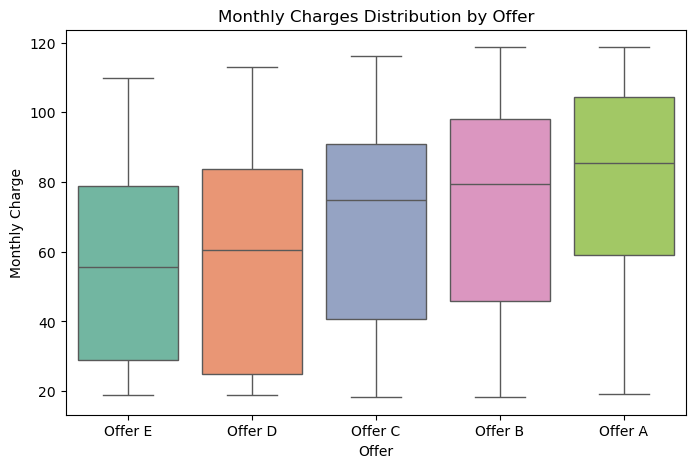

In [135]:
plt.figure(figsize=(8,5))
sb.boxplot(x="Offer", y="Monthly Charge", data=ibdata, palette="Set2")
plt.title("Monthly Charges Distribution by Offer")
plt.show()

## From the KDE plot and the offer-wise analysis of monthly charges, it is evident that Offer A has the highest average monthly charge, followed by Offers B, C, D, and E, showing a descending trend in mean monthly charges across the offers.

<Figure size 640x480 with 0 Axes>

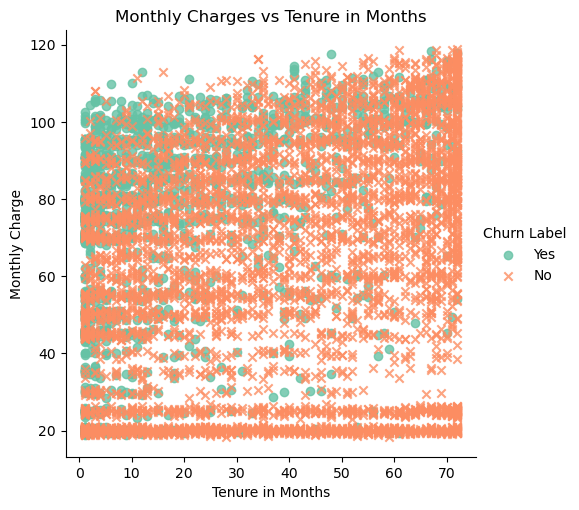

In [136]:
plt.figure()
sb.lmplot(x='Tenure in Months',y="Monthly Charge", data = ibdata ,hue="Churn Label",fit_reg=False
               ,markers=["o", "x"]
               ,palette="Set2")
plt.title("Monthly Charges vs Tenure in Months")
plt.show()

## Early customers are more likely to churn.
## High monthly charge customers in early stage are risky.
## Long tenure customers are more stable.

## This suggests that customer retention efforts should be concentrated during the early lifecycle stage, especially for customers enrolled in high-cost plans.

# Customer Churn Analysis by Offer Type

In [137]:
pd.crosstab(ibdata["Offer"], ibdata["Churn Label"], normalize="index")

Churn Label,No,Yes
Offer,,
Offer A,0.932692,0.067308
Offer B,0.877427,0.122573
Offer C,0.771084,0.228916
Offer D,0.732558,0.267442
Offer E,0.470807,0.529193


## Offer A  Best Performing Only 6.7% churn Extremely effective
## Strong retention offer 
## Offer B Good 12% churn
## Still strong
## Offer C & D Moderate Risk 23–27% churn Average effectiveness
## Offer E Very Dangerous
## More people churn than stay 53% churn rate this is a failure offer

In [138]:
ibdata["Streaming_Count"] = (
    (ibdata["Streaming TV"] == "Yes").astype(int) +
    (ibdata["Streaming Movies"] == "Yes").astype(int) +
    (ibdata["Streaming Music"] == "Yes").astype(int))

In [139]:
pd.crosstab(ibdata["Streaming_Count"], ibdata["Churn Label"], normalize="index")

Churn Label,No,Yes
Streaming_Count,,
0,0.784035,0.215965
1,0.637913,0.362087
2,0.661274,0.338726
3,0.730539,0.269461


## 0 (No streaming) Churn = 21.6% Baseline level. 
## 1 (Single service)  Churn = 36.2% Highest churn.

## 2 (Double bundle) Churn = 33.9% Still high.

## 3 (Full bundle) Churn = 26.9% Lower than 1 and 2, but higher than 0

## Partial bundle customers may be: Testing service
## Price sensitive Not fully engaged Unsatisfied with one service

## Full bundle customers: More committed Higher switching cost, More engaged ecosystem users

## No streaming customers: Maybe basic users Not dependent on streaming Less sensitive to service quality

In [140]:
pd.crosstab(
    [ibdata["Offer"], ibdata["Streaming_Count"]],
    ibdata["Churn Label"],
    normalize="index")

Churn Label                    No       Yes
Offer   Streaming_Count                    
Offer A 0                0.980645  0.019355
        1                0.959184  0.040816
        2                0.927711  0.072289
        3                0.896996  0.103004
Offer B 0                0.942492  0.057508
        1                0.871560  0.128440
        2                0.815603  0.184397
        3                0.835249  0.164751
Offer C 0                0.870647  0.129353
        1                0.689655  0.310345
        2                0.603448  0.396552
        3                0.714286  0.285714
Offer D 0                0.837079  0.162921
        1                0.574713  0.425287
        2                0.591549  0.408451
        3                0.579545  0.420455
Offer E 0                0.551657  0.448343
        1                0.312500  0.687500
        2                0.336842  0.663158
        3                0.341176  0.658824

<Axes: title={'center': 'Steaming Counts Distribution'}, ylabel='Frequency'>

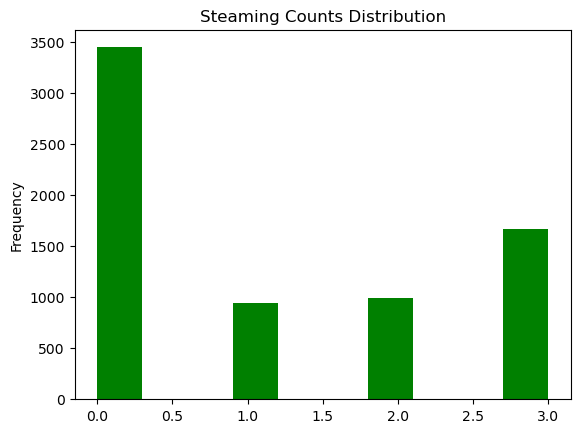

In [141]:
plt.title("Steaming Counts Distribution")
ibdata["Streaming_Count"].plot(kind = "hist",color ="g")

## The majority of customers do not subscribe to any streaming services.
## Among streaming users, customers with full bundle adoption (TV, Movies, and Music) represent the next largest segment.

In [142]:
print(*ibdata.columns, sep="\n")

Customer ID
Gender
Age
Under 30
Senior Citizen
Married
Dependents
Number of Dependents
Country
State
City
Zip Code
Latitude
Longitude
Population
Quarter
Referred a Friend
Number of Referrals
Tenure in Months
Offer
Phone Service
Avg Monthly Long Distance Charges
Multiple Lines
Internet Service
Internet Type
Avg Monthly GB Download
Online Security
Online Backup
Device Protection Plan
Premium Tech Support
Streaming TV
Streaming Movies
Streaming Music
Unlimited Data
Contract
Paperless Billing
Payment Method
Monthly Charge
Total Charges
Total Refunds
Total Extra Data Charges
Total Long Distance Charges
Total Revenue
Satisfaction Score
Customer Status
Churn Label
Churn Score
CLTV
Churn Category
Churn Reason
Churn Binary
tenure_cut
Revenue Bucket
Age Group
GB_Group
AddOn_Count
City_Grouped
cluster
Streaming_Count


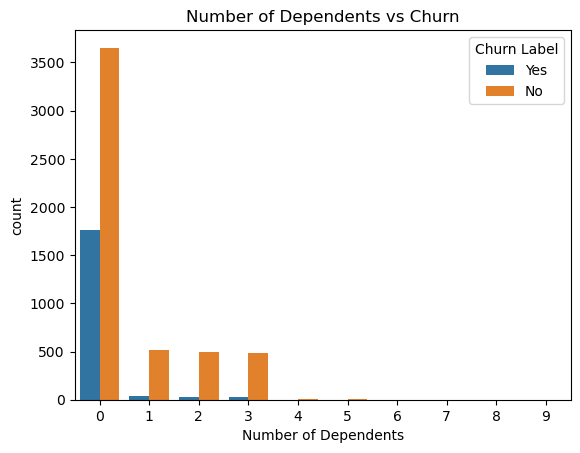

In [143]:
sb.countplot(x = "Number of Dependents",data=ibdata, hue = "Churn Label")
plt.title("Number of Dependents vs Churn")
plt.show()

## The majority of the customer (both churn and not churn are at zero dependent 
## This suggest the customer base is heavily skewed towards induvidual without dependencies

In [144]:
pd.crosstab(ibdata["Satisfaction Score"],ibdata["Churn Label"],normalize="index") * 100


Churn Label,No,Yes
Satisfaction Score,,
1,0.000000,100.000000
2,0.000000,100.000000
3,83.902439,16.097561
4,100.000000,0.000000
5,100.000000,0.000000


## Satisfaction score directly reflects customer sentiment and engagement. 
## Since it is collected prior to churn and available at prediction time, 
## Satisfaction score is a valid and strong predictor of churn behavior.

In [145]:
correv = ibdata[["Total Revenue","Tenure in Months","Monthly Charge"]].corr()
correv

,Total Revenue,Tenure in Months,Monthly Charge
Total Revenue,1.000000,0.853146,0.588887
Tenure in Months,0.853146,1.000000,0.247582
Monthly Charge,0.588887,0.247582,1.000000


In [146]:
from sklearn.preprocessing import StandardScaler

In [147]:
seg_standard = ibdata[["CLTV","Tenure in Months","Monthly Charge","Churn Binary"]]
df_kmeans_da = seg_standard[["CLTV", "Tenure in Months", "Monthly Charge"]]
sca_segment = StandardScaler().fit_transform(df_kmeans_da)

tenure_std = pd.DataFrame(sca_segment,columns=df_kmeans_da.columns)

tenure_std.head()

,CLTV,Tenure in Months,Monthly Charge
0,0.872974,-1.278988,-0.834611
1,0.762236,-0.993743,0.528063
2,-1.032395,-0.586250,1.019955
3,0.791822,-0.301005,1.121324
4,-1.358692,0.187986,0.390134


In [148]:
ibdata["Contract"].value_counts()

Contract
Month-to-Month    3610
Two Year          1883
One Year          1550
Name: count, dtype: int64

<Axes: xlabel='Contract', ylabel='count'>

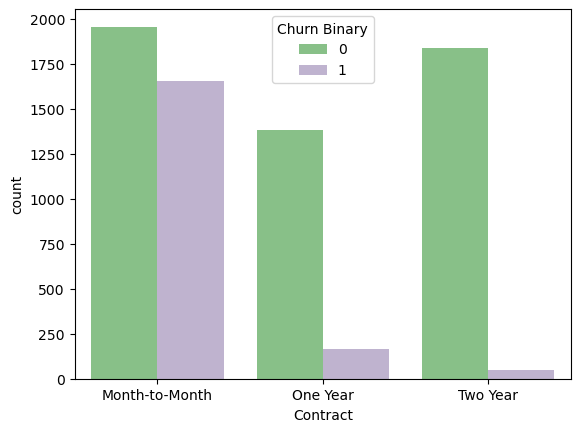

In [149]:
sb.countplot(x = "Contract",data = ibdata, hue = "Churn Binary", palette='Accent')

## Month -Month Customer Contracter churn count is high almost comparable to non churn Customer
## Churn rate is significantly high in Month-Month 
## Customers without long term commitment leave easily

In [150]:
offer_contract_churn = (
    ibdata.groupby(["Offer", "Contract"])["Churn Label"]
    .value_counts(normalize=True)
    .unstack())

offer_contract_churn

Churn Label                   No       Yes
Offer   Contract                          
Offer A Month-to-Month  0.600000  0.400000
        One Year        0.855670  0.144330
        Two Year        0.963235  0.036765
Offer B Month-to-Month  0.754630  0.245370
        One Year        0.870662  0.129338
        Two Year        0.975945  0.024055
Offer C Month-to-Month  0.591133  0.408867
        One Year        0.923077  0.076923
        Two Year        0.985507  0.014493
Offer D Month-to-Month  0.642857  0.357143
        One Year        0.945946  0.054054
        Two Year        1.000000       NaN
Offer E Month-to-Month  0.415512  0.584488
        One Year        0.900000  0.100000
        Two Year        1.000000       NaN

## Customers with month-to-month contracts exhibit the highest churn rates across all offers, whereas customers with two-year contracts show extremely low or zero churn. This indicates that long-term contracts play a crucial role in reducing churn, as customers are more committed and less likely to switch providers.

## Companies should encourage customers to move from Month-to-Month to Long-Term Contracts to reduce churn.

## Methods include:discounts bundled services loyalty rewards

In [151]:
ibdata.groupby('Payment Method')["Churn Label"].value_counts(normalize =True)

Payment Method   Churn Label
Bank Withdrawal  No             0.660015
                 Yes            0.339985
Credit Card      No             0.855220
                 Yes            0.144780
Mailed Check     No             0.631169
                 Yes            0.368831
Name: proportion, dtype: float64

## Customers who pay via credit card are significantly less likely to churn compared to customers using bank withdrawal or mailed checks.
## Customers using mailed checks show the highest churn tendency, possibly due to lower engagement with automated payment systems.
## Payment method may reflect customer engagement level.

## Credit card users more automated billing hence more loyal
## Manual payment users easier to stop service hence higher churn